# Notebook 04: Dynamic Programming

**Series:** Reinforcement Learning Basics (4/20)

---

## 1. What is Dynamic Programming?

**Dynamic Programming (DP)** solves MDPs when we have a **perfect model** (know $P$ and $R$).

**Requirements:**
- Complete knowledge of the MDP
- Finite state and action spaces

**Key idea:** Use Bellman equations as **update rules** — iterate until convergence.

## 2. Policy Evaluation (Prediction)

**Goal:** Compute $V^\pi$ for a given policy $\pi$.

**Iterative update:**
$$V_{k+1}(s) = \sum_a \pi(a|s) \sum_{s'} P(s'|s,a) \Big[ R(s,a,s') + \gamma V_k(s') \Big]$$

Start with arbitrary $V_0$, repeat until $\|V_{k+1} - V_k\|_\infty < \theta$.

**Why it converges:** The Bellman operator is a $\gamma$-contraction. Each iteration reduces the error by at least a factor of $\gamma$:
$$\|V_{k+1} - V^\pi\|_\infty \leq \gamma \|V_k - V^\pi\|_\infty$$

## 3. Policy Improvement

**Policy Improvement Theorem:** If for all $s$:
$$Q^\pi(s, \pi'(s)) \geq V^\pi(s)$$

then $\pi'$ is at least as good as $\pi$: $V^{\pi'}(s) \geq V^\pi(s)$ for all $s$.

**Greedy improvement:**
$$\pi'(s) = \arg\max_a Q^\pi(s, a) = \arg\max_a \sum_{s'} P(s'|s,a)[R(s,a,s') + \gamma V^\pi(s')]$$

## 4. Policy Iteration

1. **Initialize** $\pi_0$ arbitrarily
2. **Evaluate:** Compute $V^{\pi_k}$ (policy evaluation)
3. **Improve:** $\pi_{k+1}(s) = \arg\max_a Q^{\pi_k}(s,a)$ (greedy)
4. If $\pi_{k+1} = \pi_k$, stop. Else go to step 2.

**Guaranteed to converge** to $\pi^*$ in finite MDPs (finite number of deterministic policies).

## 5. Value Iteration

Combine evaluation and improvement into **one step**:

$$V_{k+1}(s) = \max_a \sum_{s'} P(s'|s,a) \Big[ R(s,a,s') + \gamma V_k(s') \Big]$$

This is the **Bellman optimality operator**. Converges to $V^*$.

Extract optimal policy at the end:
$$\pi^*(s) = \arg\max_a \sum_{s'} P(s'|s,a)[R(s,a,s') + \gamma V^*(s')]$$

## 6. Generalized Policy Iteration (GPI)

Almost all RL methods follow the GPI pattern:
- **Evaluation:** Make value function more accurate for current policy
- **Improvement:** Make policy more greedy w.r.t. current value function

These two processes interact and converge to optimality.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# GridWorld Setup
# ============================================
size = 4
n_states = size * size
n_actions = 4
gamma = 1.0
terminal_states = [0, 15]
moves = {0: (-1, 0), 1: (0, 1), 2: (1, 0), 3: (0, -1)}

P = np.zeros((n_states, n_actions, n_states))
R = np.zeros((n_states, n_actions, n_states))

for s in range(n_states):
    if s in terminal_states:
        for a in range(n_actions):
            P[s, a, s] = 1.0
        continue
    row, col = divmod(s, size)
    for a in range(n_actions):
        dr, dc = moves[a]
        nr, nc = max(0, min(size-1, row+dr)), max(0, min(size-1, col+dc))
        s_next = nr * size + nc
        P[s, a, s_next] = 1.0
        R[s, a, s_next] = -1.0

# ============================================
# Policy Evaluation
# ============================================
def policy_evaluation(pi, P, R, gamma, theta=1e-6):
    V = np.zeros(n_states)
    history = [V.copy()]
    while True:
        V_new = np.zeros(n_states)
        for s in range(n_states):
            for a in range(n_actions):
                for s_next in range(n_states):
                    V_new[s] += pi[s, a] * P[s, a, s_next] * (R[s, a, s_next] + gamma * V[s_next])
        if np.max(np.abs(V_new - V)) < theta:
            break
        V = V_new
        history.append(V.copy())
    return V_new, history

# Evaluate random policy
pi_random = np.ones((n_states, n_actions)) / n_actions
V_pi, pe_history = policy_evaluation(pi_random, P, R, gamma)

print("Policy Evaluation — Random Policy:")
print(V_pi.reshape(size, size).round(1))
print(f"Converged in {len(pe_history)} iterations")

Policy Evaluation — Random Policy:
[[  0. -14. -20. -22.]
 [-14. -18. -20. -20.]
 [-20. -20. -18. -14.]
 [-22. -20. -14.   0.]]
Converged in 258 iterations


In [2]:
# ============================================
# Policy Iteration
# ============================================
def policy_iteration(P, R, gamma, theta=1e-6):
    pi = np.ones((n_states, n_actions)) / n_actions
    iteration = 0
    while True:
        # Evaluate
        V, _ = policy_evaluation(pi, P, R, gamma, theta)
        # Improve
        policy_stable = True
        for s in range(n_states):
            old_action = np.argmax(pi[s])
            Q_s = np.zeros(n_actions)
            for a in range(n_actions):
                for s_next in range(n_states):
                    Q_s[a] += P[s, a, s_next] * (R[s, a, s_next] + gamma * V[s_next])
            best_a = np.argmax(Q_s)
            pi[s] = 0
            pi[s, best_a] = 1.0
            if old_action != best_a:
                policy_stable = False
        iteration += 1
        if policy_stable:
            break
    return pi, V, iteration

pi_star, V_star_pi, pi_iters = policy_iteration(P, R, gamma)
print(f"Policy Iteration converged in {pi_iters} iterations")
print("Optimal V*:")
print(V_star_pi.reshape(size, size).round(1))

# Show optimal policy
arrows = ['↑', '→', '↓', '←']
policy_grid = np.array([arrows[np.argmax(pi_star[s])] for s in range(n_states)]).reshape(size, size)
policy_grid[0, 0] = 'T'
policy_grid[size-1, size-1] = 'T'
print("\nOptimal Policy:")
for row in policy_grid:
    print(' '.join(row))

Policy Iteration converged in 3 iterations
Optimal V*:
[[ 0. -1. -2. -3.]
 [-1. -2. -3. -2.]
 [-2. -3. -2. -1.]
 [-3. -2. -1.  0.]]

Optimal Policy:
T ← ← ↓
↑ ↑ ↑ ↓
↑ ↑ → ↓
↑ → → T


Value Iteration converged in 4 iterations
V* (Value Iteration):
[[ 0. -1. -2. -3.]
 [-1. -2. -3. -2.]
 [-2. -3. -2. -1.]
 [-3. -2. -1.  0.]]


<>:44: SyntaxWarning: invalid escape sequence '\|'
<>:44: SyntaxWarning: invalid escape sequence '\|'
C:\Users\Milan Amrut Joshi\AppData\Local\Temp\ipykernel_51168\2272336065.py:44: SyntaxWarning: invalid escape sequence '\|'
  axes[0].set_ylabel('$\|V_k - V^*\|_\infty$')


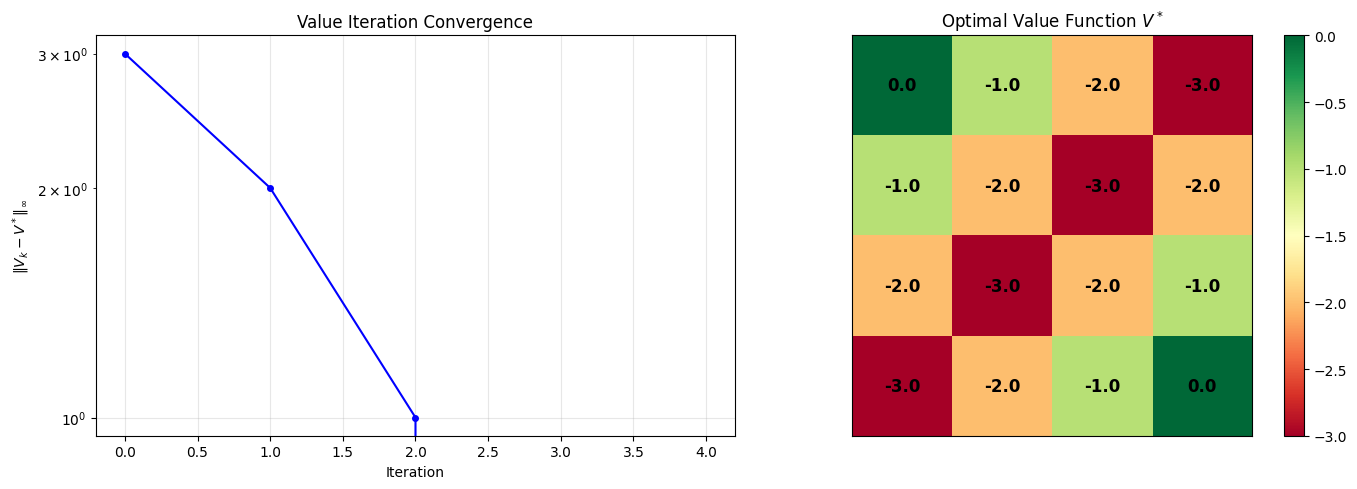

In [3]:
# ============================================
# Value Iteration
# ============================================
def value_iteration(P, R, gamma, theta=1e-6):
    V = np.zeros(n_states)
    history = [V.copy()]
    iteration = 0
    while True:
        V_new = np.zeros(n_states)
        for s in range(n_states):
            Q_s = np.zeros(n_actions)
            for a in range(n_actions):
                for s_next in range(n_states):
                    Q_s[a] += P[s, a, s_next] * (R[s, a, s_next] + gamma * V[s_next])
            V_new[s] = np.max(Q_s)
        iteration += 1
        history.append(V_new.copy())
        if np.max(np.abs(V_new - V)) < theta:
            break
        V = V_new

    # Extract policy
    pi = np.zeros((n_states, n_actions))
    for s in range(n_states):
        Q_s = np.zeros(n_actions)
        for a in range(n_actions):
            for s_next in range(n_states):
                Q_s[a] += P[s, a, s_next] * (R[s, a, s_next] + gamma * V_new[s_next])
        pi[s, np.argmax(Q_s)] = 1.0
    return pi, V_new, history

pi_vi, V_star_vi, vi_history = value_iteration(P, R, gamma)
print(f"Value Iteration converged in {len(vi_history)-1} iterations")
print("V* (Value Iteration):")
print(V_star_vi.reshape(size, size).round(1))

# Convergence plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Value Iteration convergence
errors = [np.max(np.abs(vi_history[i] - V_star_vi)) for i in range(len(vi_history))]
axes[0].semilogy(errors, 'b-o', markersize=4)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('$\|V_k - V^*\|_\infty$')
axes[0].set_title('Value Iteration Convergence')
axes[0].grid(True, alpha=0.3)

# Heatmap of V*
im = axes[1].imshow(V_star_vi.reshape(size, size), cmap='RdYlGn')
for i in range(size):
    for j in range(size):
        axes[1].text(j, i, f'{V_star_vi[i*size+j]:.1f}', ha='center', va='center', fontsize=12, fontweight='bold')
axes[1].set_title('Optimal Value Function $V^*$')
axes[1].set_xticks([]); axes[1].set_yticks([])
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

## Summary

| Algorithm | Update | Complexity per Sweep |
|-----------|--------|---------------------|
| **Policy Evaluation** | $V_{k+1}(s) = \sum_a \pi(a|s) \sum_{s'} P[R + \gamma V_k(s')]$ | $O(|\mathcal{S}|^2 |\mathcal{A}|)$ |
| **Policy Iteration** | Evaluate $\to$ Improve $\to$ repeat | Converges in few iterations |
| **Value Iteration** | $V_{k+1}(s) = \max_a \sum_{s'} P[R + \gamma V_k(s')]$ | $O(|\mathcal{S}|^2 |\mathcal{A}|)$ |

**Limitation:** DP requires a complete model. Next we learn **model-free** methods.

**Next:** Notebook 05 — Monte Carlo Methods